# sensors analysis — summary

## data
Temperature, humidity, CO2, and static accelerations (x,y,z) every ten minutes.

## missing data
CO2 is missing from hive 2 and 3, so we disregard it for now.
Hive 6 file is missing.
Thus only temperature and humidity will be extracted to be added as indicators/features to the audio ones.
Since some temperature/humidity measurements have sporadic shifts to 35 degrees and 50% humidity,
this is likely due to the bee cluster moving close to the sensor.

## extracted data
A single aggregated temperature and humidity indicator for all hives will be extracted.
It is based on the mode of the 11 hives' measurements to represent the ambient baseline.
Note: Hive 11 is a dummy (no bees), so its readings are purely ambient.

In [1]:
from pipe import (Pipe, tee)
import numpy
import pandas
import matplotlib.pyplot
import paths

def timestamps_and_columns_from_sensors_filepath(filepath, usecols):
    expected_header = 'timestamp,sht_t,sht_h,co2,scd_t,scd_h,accel_x,accel_y,accel_z,rssi'
    with open(filepath, mode='r') as stream:
        assert stream.readline().strip() == expected_header, "unexpected header"
    columns = numpy.genfromtxt(filepath, delimiter=',', skip_header=1, usecols=usecols, dtype=numpy.float32)
    if columns.ndim == 1:
        columns = columns.reshape(-1, 1)
    assert columns.ndim == 2
    timestamps = numpy.genfromtxt(filepath, delimiter=',', skip_header=1, usecols=0, dtype='datetime64[s]')
    assert timestamps.shape[0] == columns.shape[0]
    return timestamps, columns


@Pipe
def timestamps_and_temperatures_and_humidities_from_sensors_filepath(filepath):
    timestamps, columns = timestamps_and_columns_from_sensors_filepath(filepath, usecols=(1, 2))
    return timestamps, columns[:, 0], columns[:, 1]


@Pipe
def timestamps_and_co2s_from_sensors_filepath(filepath):
    timestamps, columns = timestamps_and_columns_from_sensors_filepath(filepath, usecols=(3,))
    return timestamps, columns[:, 0]

In [3]:
for hive_number in [1,2,3,4,5,7,8,9,10,11]:
    filepath = hive_number | Pipe(paths.hive_sensors_filepath_from_hive_number)
    timestamps, columns = timestamps_and_columns_from_sensors_filepath(filepath, usecols=(1, 2, 3))
    nan_counts = numpy.isnan(columns).sum(axis=0)
    print(
        f"hive {hive_number:2d}: {len(timestamps):6d} rows | "
        f"temp NaN:{int(nan_counts[0]):5d} | "
        f"humid NaN:{int(nan_counts[1]):5d} | "
        f"co2 NaN:{int(nan_counts[2]):5d}"
    )

hive  1:   2599 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN:    0
hive  2:   2647 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN:    0
hive  3:   2175 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN: 2175
hive  4:   2157 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN: 2157
hive  5:   2604 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN: 2604
hive  7:   2611 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN: 2611
hive  8:   2591 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN: 2591
hive  9:   2608 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN: 2608
hive 10:   2608 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN: 2608
hive 11:   2633 rows | temp NaN:    0 | humid NaN:    0 | co2 NaN: 2633


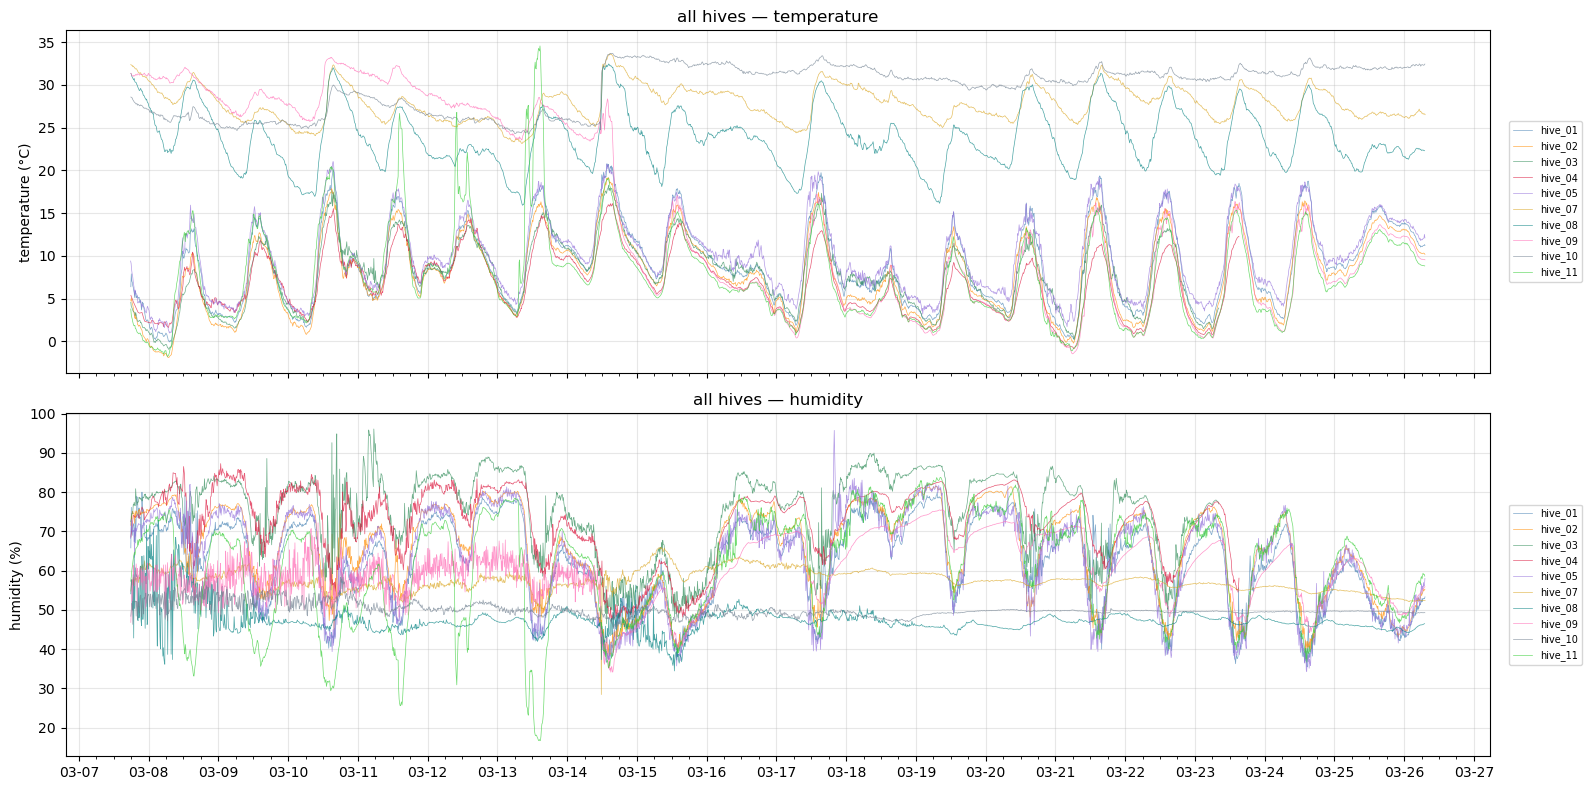

In [5]:
import matplotlib.dates

HIVE_COLORS = [
    'steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple',
    'goldenrod', 'teal', 'hotpink', 'slategray', 'limegreen', 'dodgerblue',
]

figure, (temp_axis, humid_axis) = matplotlib.pyplot.subplots(
    2, 1, figsize=(16, 8), sharex=True,
)

for hive_number, color in zip([1, 2, 3, 4, 5, 7, 8, 9, 10, 11], HIVE_COLORS):
    timestamps, temperatures, humidities = (
        hive_number
        | Pipe(paths.hive_sensors_filepath_from_hive_number)
        | Pipe(timestamps_and_temperatures_and_humidities_from_sensors_filepath)
    )
    label = f"hive_{hive_number:02d}"
    temp_axis.plot(timestamps, temperatures, color=color, alpha=0.7, linewidth=0.5, label=label)
    humid_axis.plot(timestamps, humidities, color=color, alpha=0.7, linewidth=0.5, label=label)

for axis in (temp_axis, humid_axis):
    axis.grid(True, alpha=0.3)
    axis.xaxis.set_major_locator(matplotlib.dates.DayLocator())
    axis.xaxis.set_minor_locator(matplotlib.dates.HourLocator(byhour=range(0, 24, 6)))
    axis.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%m-%d'))
    axis.legend(fontsize=7, ncol=1, loc='center left', bbox_to_anchor=(1.01, 0.5))

temp_axis.set_ylabel('temperature (°C)')
temp_axis.set_title('all hives — temperature')
humid_axis.set_ylabel('humidity (%)')
humid_axis.set_title('all hives — humidity')
figure.tight_layout()
matplotlib.pyplot.show()

In [7]:
figure.savefig(paths.pictures_folderpath + 'ambient_raw' , dpi=150)

hive  3: no valid CO2 data — skipped
hive  4: no valid CO2 data — skipped
hive  5: no valid CO2 data — skipped
hive  7: no valid CO2 data — skipped
hive  8: no valid CO2 data — skipped
hive  9: no valid CO2 data — skipped
hive 10: no valid CO2 data — skipped
hive 11: no valid CO2 data — skipped


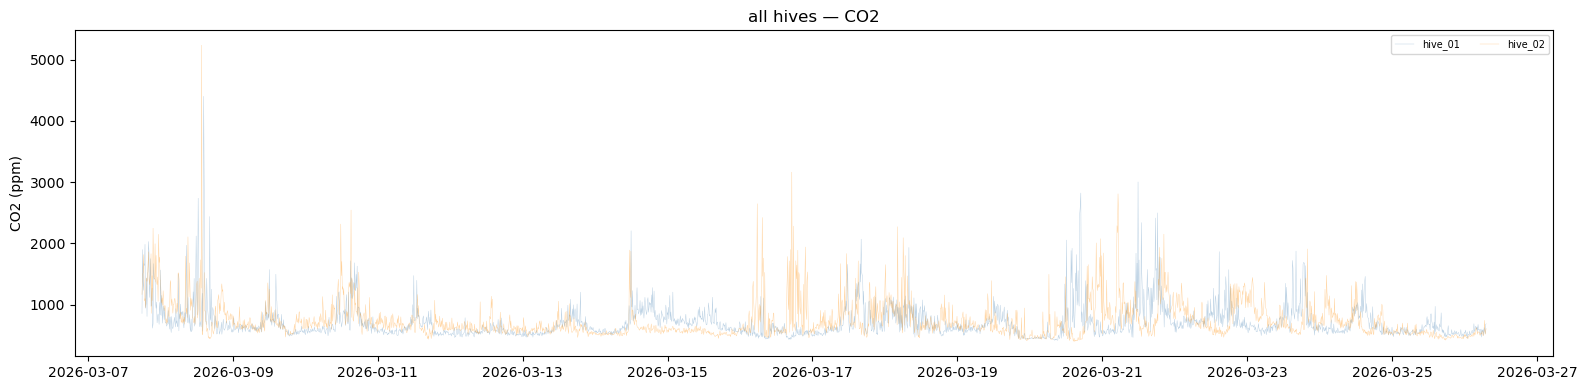

In [9]:
figure, axis = matplotlib.pyplot.subplots(figsize=(16, 4))

for hive_number, color in zip([1,2,3,4,5,7,8,9,10,11], HIVE_COLORS):
    timestamps, co2s = (
        hive_number
        | Pipe(paths.hive_sensors_filepath_from_hive_number)
        | Pipe(timestamps_and_co2s_from_sensors_filepath)
    )
    valid_mask = ~numpy.isnan(co2s)
    if valid_mask.sum() == 0:
        print(f"hive {hive_number:2d}: no valid CO2 data — skipped")
        continue
    axis.plot(
        timestamps[valid_mask], co2s[valid_mask],
        color=color, alpha=0.4, linewidth=0.3,
        label=f"hive_{hive_number:02d}",
    )

axis.set_ylabel('CO2 (ppm)')
axis.set_title('all hives — CO2')
axis.legend(fontsize=7, ncol=4)
figure.tight_layout()
matplotlib.pyplot.show()

In [10]:
from pipe import Pipe, select
import numpy
import pandas
import matplotlib.pyplot
import matplotlib.dates
import os
import paths



In [11]:

# --- dense cluster median ---

def dense_cluster_median_from_values(values):
    sorted_values = numpy.sort(values)
    if len(sorted_values) <= 2:
        return numpy.median(sorted_values)
    gaps = numpy.diff(sorted_values)
    split = numpy.argmax(gaps)
    left = sorted_values[:split + 1]
    right = sorted_values[split + 1:]
    return numpy.median(left if len(left) >= len(right) else right)




In [20]:
# --- per-hive loading ---
def timestamps_and_temperatures_and_humidities_from_hive_number(hive_number):
    return (
        hive_number
        | Pipe(paths.hive_sensors_filepath_from_hive_number)
        | Pipe(timestamps_and_temperatures_and_humidities_from_sensors_filepath)
    )



In [21]:

# --- hourly aggregation ---

@Pipe
def hourly_dense_median_series_from_per_hive_hourlies(per_hive_hourlies):
    combined = pandas.concat(per_hive_hourlies)
    return combined.groupby(level=0).agg(
        temperature=('temperature', dense_cluster_median_from_values),
        humidity=('humidity', dense_cluster_median_from_values),
    ).reset_index().rename(columns={'hour': 'timestamp'})


@Pipe
def hourly_dense_median_dataframe_from_hive_numbers(hive_numbers):
    per_hive_hourlies = list(
        hive_numbers
        | select(timestamps_and_temperatures_and_humidities_from_hive_number)
        | select(lambda hour_temp_humid: pandas.DataFrame({
            'hour': hour_temp_humid[0].astype('datetime64[h]'),
            'temperature': hour_temp_humid[1],
            'humidity': hour_temp_humid[2],
        }).groupby('hour').median())
    )
    return per_hive_hourlies | hourly_dense_median_series_from_per_hive_hourlies


In [27]:

@Pipe
def plot_temperatures_and_humidities_from_hive_triples_and_names(
    triples,
    hive_names,
    aggregate_dataframe=None,
):

    HIVE_COLORS = [
        'steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple',
        'goldenrod', 'teal', 'hotpink', 'slategray', 'limegreen', 'dodgerblue',
    ]

    
    figure, (temp_axis, humid_axis) = matplotlib.pyplot.subplots(
        2, 1, figsize=(16, 8), sharex=True,
    )

    for (timestamps, temperatures, humidities), name, color in zip(triples, hive_names, HIVE_COLORS):
        temp_axis.plot(timestamps, temperatures, color=color, alpha=0.3, linewidth=0.3, label=name)
        humid_axis.plot(timestamps, humidities, color=color, alpha=0.3, linewidth=0.3, label=name)

    if aggregate_dataframe is not None:
        temp_axis.plot(
            aggregate_dataframe['timestamp'], aggregate_dataframe['temperature'],
            color='black', linewidth=2, label='dense cluster median',
        )
        humid_axis.plot(
            aggregate_dataframe['timestamp'], aggregate_dataframe['humidity'],
            color='black', linewidth=2, label='dense cluster median',
        )

    for axis in (temp_axis, humid_axis):
        axis.grid(True, alpha=0.3)
        axis.xaxis.set_major_locator(matplotlib.dates.DayLocator())
        axis.xaxis.set_minor_locator(matplotlib.dates.HourLocator(byhour=range(0, 24, 6)))
        axis.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%m-%d'))
        axis.legend(fontsize=7, ncol=1, loc='center left', bbox_to_anchor=(1.01, 0.5))

    temp_axis.set_ylabel('temperature (°C)')
    temp_axis.set_title('temperature')
    humid_axis.set_ylabel('humidity (%)')
    humid_axis.set_title('humidity')
    figure.tight_layout()
    return figure
    # matplotlib.pyplot.show()

In [23]:
HIVE_NUMBERS = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11]
HIVE_NAMES = [f"hive_{n:02d}" for n in HIVE_NUMBERS]

triples =(
    (
        hive_number
        | Pipe(paths.hive_sensors_filepath_from_hive_number)
        | Pipe(timestamps_and_temperatures_and_humidities_from_sensors_filepath)
    ) for hive_number in [1, 2, 3, 4, 5, 7, 8, 9, 10, 11]
)
# [timestamps_and_temperatures_and_humidities_from_hive_number(n) for n in HIVE_NUMBERS]


In [24]:
hourly_dataframe = (
    HIVE_NUMBERS
    | hourly_dense_median_dataframe_from_hive_numbers
)

In [25]:
hourly_dataframe

,timestamp,temperature,humidity
0,2026-03-07 17:00:00,5.0450,54.070000
1,2026-03-07 18:00:00,4.4775,56.215000
2,2026-03-07 19:00:00,3.6400,72.297501
3,2026-03-07 20:00:00,2.8625,74.245003
4,2026-03-07 21:00:00,2.7600,70.949997
...,...,...,...
442,2026-03-26 03:00:00,11.6700,51.610001
443,2026-03-26 04:00:00,10.7850,52.345001
444,2026-03-26 05:00:00,10.3550,53.004997
445,2026-03-26 06:00:00,10.2700,54.970001


# assess synthetic inter temperature and himidity indicator

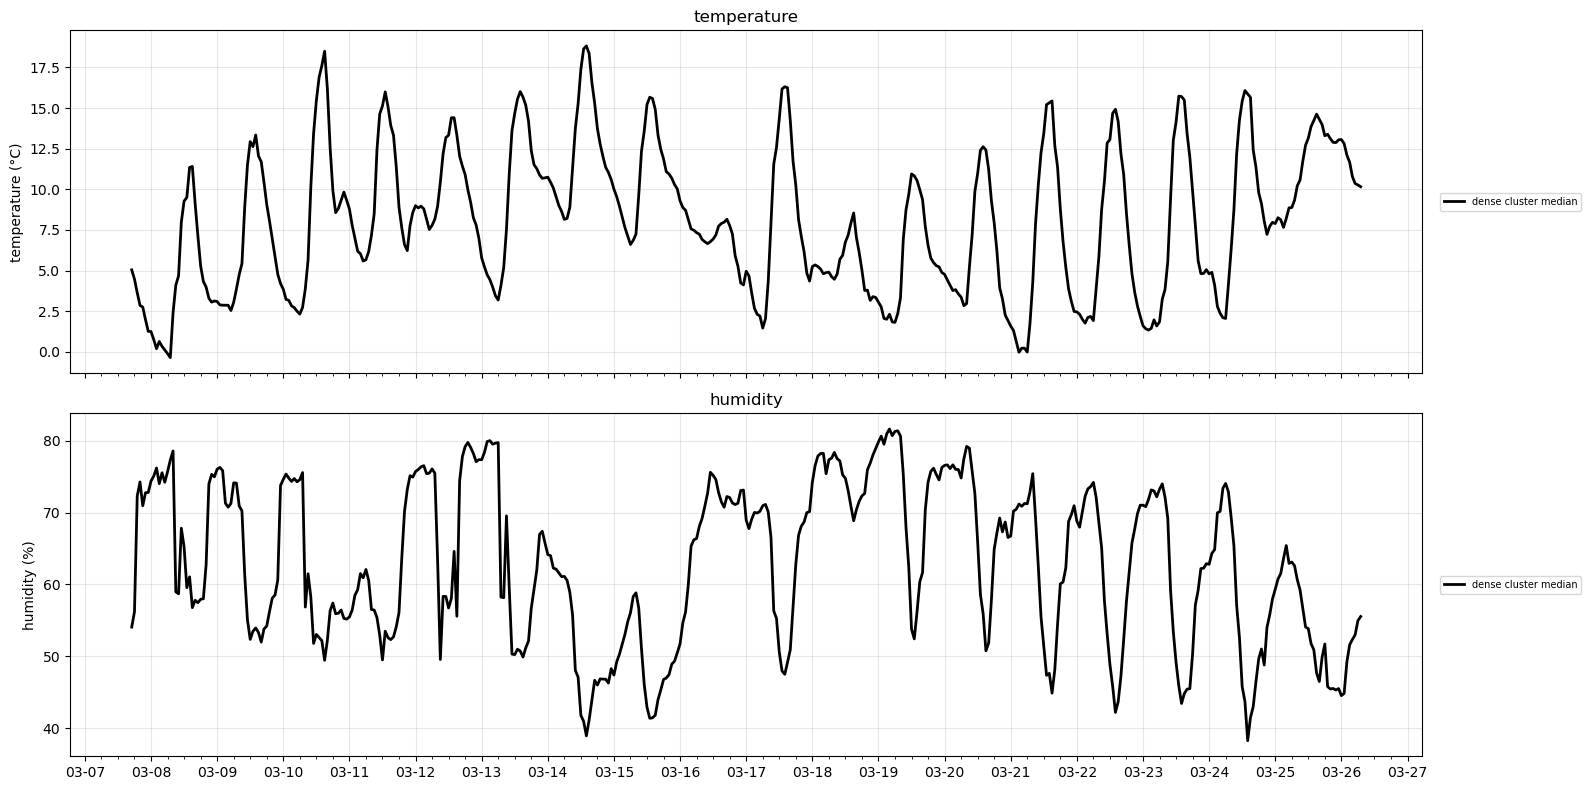

In [29]:
(
    triples
    |
    plot_temperatures_and_humidities_from_hive_triples_and_names(
        hive_names=HIVE_NAMES,
        aggregate_dataframe=hourly_dataframe,
    )
).savefig(paths.pictures_folderpath + 'ambient_aggreagation' , dpi=150)

In [ ]:
hourly_dataframe

In [ ]:
# --- save ---

def saved_csv_filepath_from_dataframe(dataframe, filename):
    os.makedirs(paths.features_folderpath, exist_ok=True)
    filepath = os.path.join(paths.features_folderpath, filename)
    dataframe.to_csv(filepath, index=False)
    print(f"saved {len(dataframe)} rows to {filepath}")
    return filepath


In [ ]:

saved_csv_filepath_from_features_dataframe(hourly_dataframe, paths.ambient_features_filename)

In [ ]:
figure, axis = matplotlib.pyplot.subplots(figsize=(16, 5))

for hive_number, color in zip([1, 2, 3, 4, 5, 7, 8, 9, 10, 11], HIVE_COLORS):
    timestamps, temperatures, _ = (
        hive_number
        | Pipe(paths.hive_sensors_filepath_from_hive_number)
        | Pipe(timestamps_and_temperatures_and_humidities_from_sensors_filepath)
    )
    hive_df = pandas.DataFrame({
        'hour': timestamps.astype('datetime64[h]'),
        'temperature': temperatures,
    }).groupby('hour').median().reset_index()
    axis.plot(
        hive_df['hour'], hive_df['temperature'],
        color=color, linewidth=0.5, alpha=0.7,
        label=f"hive_{hive_number:02d}",
    )

axis.set_ylabel('temperature (°C)')
axis.set_title('per-hive hourly median temperature')
axis.grid(True, alpha=0.3)
axis.legend(fontsize=7, ncol=1, loc='center left', bbox_to_anchor=(1.01, 0.5))
figure.tight_layout()
matplotlib.pyplot.show()

In [ ]:
def hourly_dense_cluster_dataframe_from_hive_numbers(hive_numbers, min_fraction=0.6):

    def dense_cluster_center(values):
        sorted_values = numpy.sort(values)
        n = len(sorted_values)
        window_size = max(int(numpy.ceil(n * min_fraction)), 1)
        if window_size >= n:
            return numpy.median(sorted_values)
        spans = sorted_values[window_size - 1:] - sorted_values[:n - window_size + 1]
        best_start = numpy.argmin(spans)
        return numpy.median(sorted_values[best_start:best_start + window_size])

    per_hive_hourlies = []
    for hive_number in hive_numbers:
        timestamps, temperatures, humidities = (
            hive_number
            | Pipe(paths.hive_sensors_filepath_from_hive_number)
            | Pipe(timestamps_and_temperatures_and_humidities_from_sensors_filepath)
        )
        hive_df = pandas.DataFrame({
            'hour': timestamps.astype('datetime64[h]'),
            'temperature': temperatures,
            'humidity': humidities,
        }).groupby('hour').median()
        per_hive_hourlies.append(hive_df)

    combined = pandas.concat(per_hive_hourlies)
    hourly = combined.groupby(level=0).agg(
        temperature=('temperature', dense_cluster_center),
        humidity=('humidity', dense_cluster_center),
    ).reset_index()
    hourly.rename(columns={'hour': 'timestamp'}, inplace=True)
    return hourly

In [ ]:
def hourly_dense_median_dataframe_from_hive_numbers(hive_numbers):

    def dense_cluster_median(values):
        sorted_values = numpy.sort(values)
        if len(sorted_values) <= 2:
            return numpy.median(sorted_values)
        gaps = numpy.diff(sorted_values)
        split = numpy.argmax(gaps)
        left = sorted_values[:split + 1]
        right = sorted_values[split + 1:]
        return numpy.median(left if len(left) >= len(right) else right)

    per_hive_hourlies = []
    for hive_number in hive_numbers:
        timestamps, temperatures, humidities = (
            hive_number
            | Pipe(paths.hive_sensors_filepath_from_hive_number)
            | Pipe(timestamps_and_temperatures_and_humidities_from_sensors_filepath)
        )
        hive_df = pandas.DataFrame({
            'hour': timestamps.astype('datetime64[h]'),
            'temperature': temperatures,
            'humidity': humidities,
        }).groupby('hour').median()
        per_hive_hourlies.append(hive_df)

    combined = pandas.concat(per_hive_hourlies)
    hourly = combined.groupby(level=0).agg(
        temperature=('temperature', dense_cluster_median),
        humidity=('humidity', dense_cluster_median),
    ).reset_index()
    hourly.rename(columns={'hour': 'timestamp'}, inplace=True)
    return hourly


hourly_dataframe = hourly_dense_median_dataframe_from_hive_numbers(
    [1, 2, 3, 4, 5, 7, 8, 9, 10, 11],
)

figure, (temp_axis, humid_axis) = matplotlib.pyplot.subplots(
    2, 1, figsize=(16, 6), sharex=True,
)
temp_axis.plot(hourly_dataframe['timestamp'], hourly_dataframe['temperature'], color='tomato', linewidth=0.8)
temp_axis.set_ylabel('temperature (°C)')
temp_axis.set_title('hourly dense cluster median — temperature')
temp_axis.grid(True, alpha=0.3)

humid_axis.plot(hourly_dataframe['timestamp'], hourly_dataframe['humidity'], color='steelblue', linewidth=0.8)
humid_axis.set_ylabel('humidity (%)')
humid_axis.set_title('hourly dense cluster median — humidity')
humid_axis.grid(True, alpha=0.3)

figure.tight_layout()
matplotlib.pyplot.show()

In [ ]:
figure, (temp_axis, humid_axis) = matplotlib.pyplot.subplots(
    2, 1, figsize=(16, 8), sharex=True,
)

for hive_number, color in zip([1, 2, 3, 4, 5, 7, 8, 9, 10, 11], HIVE_COLORS):
    timestamps, temperatures, humidities = (
        hive_number
        | Pipe(paths.hive_sensors_filepath_from_hive_number)
        | Pipe(timestamps_and_temperatures_and_humidities_from_sensors_filepath)
    )
    label = f"hive_{hive_number:02d}"
    temp_axis.plot(timestamps, temperatures, color=color, alpha=0.3, linewidth=0.3, label=label)
    humid_axis.plot(timestamps, humidities, color=color, alpha=0.3, linewidth=0.3, label=label)

temp_axis.plot(hourly_dataframe['timestamp'], hourly_dataframe['temperature'], color='black', linewidth=2, label='dense cluster median')
humid_axis.plot(hourly_dataframe['timestamp'], hourly_dataframe['humidity'], color='black', linewidth=2, label='dense cluster median')

for axis in (temp_axis, humid_axis):
    axis.grid(True, alpha=0.3)
    axis.xaxis.set_major_locator(matplotlib.dates.DayLocator())
    axis.xaxis.set_minor_locator(matplotlib.dates.HourLocator(byhour=range(0, 24, 6)))
    axis.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%m-%d'))
    axis.legend(fontsize=7, ncol=1, loc='center left', bbox_to_anchor=(1.01, 0.5))

temp_axis.set_ylabel('temperature (°C)')
temp_axis.set_title('all hives + dense cluster median — temperature')
humid_axis.set_ylabel('humidity (%)')
humid_axis.set_title('all hives + dense cluster median — humidity')
figure.tight_layout()
matplotlib.pyplot.show()

In [ ]:
for hive_number in [1, 2, 3, 4, 5, 7, 8, 9, 10, 11]:
    timestamps, _, _ = (
        hive_number
        | Pipe(paths.hive_sensors_filepath_from_hive_number)
        | Pipe(timestamps_and_temperatures_and_humidities_from_sensors_filepath)
    )
    deltas = numpy.diff(timestamps).astype('timedelta64[s]').astype(float)
    print(
        f"hive {hive_number:2d}: {len(timestamps):6d} rows | "
        f"median interval: {numpy.median(deltas):5.0f}s | "
        f"min: {numpy.min(deltas):5.0f}s | "
        f"max: {numpy.max(deltas):7.0f}s"
    )

In [ ]:
raise

In [ ]:
from pipe import select, chain, where, take, tee, Pipe

sink = lambda f: Pipe(lambda iterable: f(list(iterable)))
stow = lambda f: Pipe(lambda args, **kwargs: f(*args, **kwargs))
compose = lambda f, g: (lambda *args, **kwargs: g(*f(*args, **kwargs)))
def identity(x): return x

In [ ]:
import paths

In [ ]:
import numpy


def timestamps_and_rest_from_sensors_filepath(filepath, usecols):
    expected_header = 'timestamp,sht_t,sht_h,co2,scd_t,scd_h,accel_x,accel_y,accel_z,rssi'
    with open(filepath, mode='r') as stream:
        assert stream.readline().strip() == expected_header, "unexpected header"
    rest = numpy.genfromtxt(filepath, delimiter=',', skip_header=1, usecols=usecols, dtype=numpy.float32)
    assert rest.ndim == 2, f"expected 2d array, got {rest.ndim}d"
    assert rest.shape[0] > 0, "no data rows"
    timestamps = numpy.genfromtxt(filepath, delimiter=',', skip_header=1, usecols=0, dtype='datetime64[s]')
    assert timestamps.shape[0] == rest.shape[0], (
        f"timestamp count {timestamps.shape[0]} != data row count {rest.shape[0]} — unparseable timestamps"
    )
    return timestamps, rest

@Pipe
def hive_timestamps_and_temperatures_and_humidities_from_sensors_filepath(filepath):
    timestamps, rest = timestamps_and_rest_from_sensors_filepath(filepath, usecols=(1, 2))
    assert not numpy.any(numpy.isnan(rest[:, 0])), "sht_t contains NaN"
    assert not numpy.any(numpy.isnan(rest[:, 1])), "sht_h contains NaN"
    return timestamps, rest[:, 0], rest[:, 1]

@Pipe
def hive_timestamps_and_co2s_from_sensors_filepath(filepath):
    timestamps, rest = timestamps_and_rest_from_sensors_filepath(filepath, usecols=(3,))
    assert not numpy.any(numpy.isnan(rest[:, 0])), "co2 contains NaN"
    assert not numpy.any(rest[:, 0] < 0), "co2 contains negative values"
    return timestamps, rest[:, 0].astype(numpy.uint16)

In [ ]:
(
    paths.hive_sensors_filepath_from_hive_number(2)
    | hive_timestamps_and_temperatures_and_humidities_from_sensors_filepath
)

In [ ]:
import pandas
def dataframe_from_hive_timestamps_and_temperatures_and_humidities(timestamps, temperature, humidity):
    print(timestamps)
    return pandas.DataFrame({
        'timestamp': timestamps,
        'temperature': temperature,
        'humidity': humidity,
    })

def merge_hive_temperature_and_humidity_to_audio_dataframe(audio_dataframe, timestamps_and_temperature_and_humidity):
    timestamps, temperatures, humidities = timestamps_and_temperature_and_humidity
    sensor_dataframe = temperature_and_humidity_dataframe_from_arrays(timestamps, temperatures, humidities)
    return pandas.merge_asof(audio_dataframe, sensor_dataframe, on='timestamp', direction='backward')

In [ ]:
(
    paths.hive_sensors_filepath_from_hive_number(2)
    | hive_timestamps_and_temperatures_and_humidities_from_sensors_filepath
    | stow(dataframe_from_hive_timestamps_and_temperatures_and_humidities)
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_temperatures_and_humidities_over_time_from(timestamps, temperatures, humidities):

    figure, (temperature_axis, humidity_axis) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    temperature_axis.plot(timestamps, temperatures, color='tomato')
    temperature_axis.set_ylabel('temperature (°C)')

    humidity_axis.plot(timestamps, humidities, color='steelblue')
    humidity_axis.set_ylabel('humidity (%)')

    for axis in (temperature_axis, humidity_axis):
        axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        axis.grid(True, alpha=0.3)

    figure.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [ ]:
(
    paths.hive_sensors_filepath_from_hive_number(1)
    | hive_timestamps_and_temperatures_and_humidities_from_sensors_filepath
    | stow(plot_temperatures_and_humidities_over_time_from)
)
(
    paths.hive_sensors_filepath_from_hive_number(10)
    | hive_timestamps_and_temperatures_and_humidities_from_sensors_filepath
    | stow(plot_temperatures_and_humidities_over_time_from)
)

In [ ]:
(
    paths.hive_sensors_filepath_from_hive_number(11)
    | hive_timestamps_and_temperatures_and_humidities_from_sensors_filepath
    | stow(plot_temperatures_and_humidities_over_time_from)
)

In [ ]:
(
    paths.hive_sensors_filepath_from_hive_number(8)
    | hive_timestamps_and_temperatures_and_humidities_from_sensors_filepath
    | stow(plot_temperatures_and_humidities_over_time_from)
)